# Least-Squares

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# n-Degree Polynomial: $$ y = a_0 + a_1x + a_2x^2 + ... + a_nx^n $$

Least-Squares Solution: [-2.00000000e+00 -1.15467531e-17  5.00000000e-01]
Residual = 1.922962686383564e-15


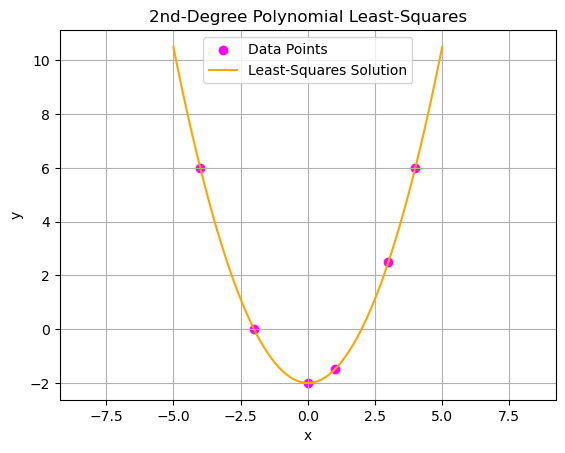

In [3]:
# specify polynomial degree
n = 2

# input data points
x = np.array([-4.0, -2.0, 0.0, 1.0, 3.0, 4.0])
y = np.array([6.0, 0.0, -2.0, -1.5, 2.5, 6.0])

if len(x) != len(y):
    raise ValueError("Number of x and y coordinates must be the same")

# set up system
A = np.ones((len(x),n+1))
for i in range(len(x)):
    for j in range(n+1):
        A[i][j] = x[i]**j
b = y
A_T = np.transpose(A)
inv = np.linalg.inv(A_T @ A)

ls_soln = inv @ (A_T @ b)
residual = np.linalg.norm(A @ ls_soln - b)


# smoothen data
x_smooth = np.linspace(min(x)-1,max(x)+1, 100)
y_bf = np.zeros_like(x_smooth)

for i in range(n+1):
    terms = ls_soln[i]*(x_smooth**i)
    y_bf = y_bf + terms

# display results
print('Least-Squares Solution:', ls_soln)
print('Residual =', residual)

if (n%10 == 1) and (n%100 != 11):
    suf = 'st'
elif (n%10 == 2) and (n%100 != 12):
    suf = 'nd'
elif (n%10 == 3) and (n%100 != 13):
    suf = 'rd'
else:
    suf = 'th'

plt.scatter(x,y, color='magenta', label='Data Points')
plt.plot(x_smooth,y_bf, color='orange', label='Least-Squares Solution')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'{n}{suf}-Degree Polynomial Least-Squares')
plt.grid()
plt.legend()
plt.axis('equal') 
plt.show()

## Conic Section: $$ 0 = Ax^2 + Bxy + Cy^2 + Dx + Ey + F $$

Best fit conic section: Hyperbolic
Least-Squares Solution: [ 0.05267919 -0.20712518  0.07315939  0.06179424  0.55339477]
Residual = 0.14704828533954933


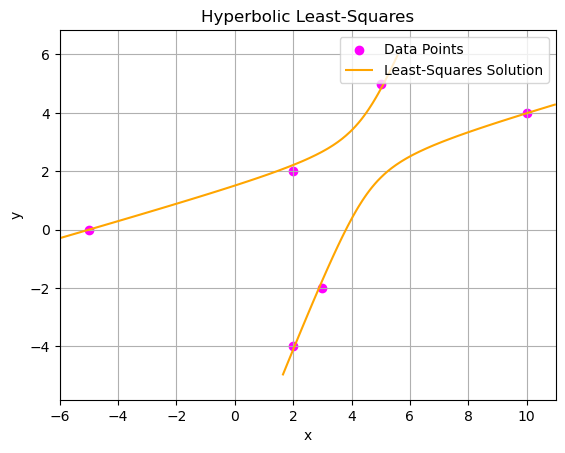

In [4]:
# example data:

# near-circular:
# x = np.array([5.0, 0.0, -5.0, 0.0, 3.5])
# y = np.array([0.0, 5.0, 0.0, -5.0, 3.5])

# hyperbolic:
# x = np.array([-13.0, -np.sqrt(41), -5.0, 5.0, np.sqrt(41), 13.0])
# y = np.array([-12.0, -4.0, 0.0, 0.0, 4.0, 12.0])

# elliptical:
# x = np.array([-5.0, -4.0, 0.0, 0.0, 4.0, 5.0])
# y = np.array([0.0, 1.8, -3.0, 3.0, -1.8, 0.0])

# parabolic: 
# x = np.array([-4.0, -2.0, 0.0, 1.0, 3.0, 4.0])
# y = np.array([6.0, 0.0, -2.0, -1.5, 2.5, 6.0])

x = np.array([3.0, 2.0, -5.0, 5.0, 10, 2.0])
y = np.array([-2.0, -4.0, 0.0, 5.0, 4.0, 2.0])

if len(x) != len(y):
    raise ValueError("Number of x and y coordinates must be the same")

# set up system
M = -1*np.ones((len(x),5)) # sets F=-1 to avoid trivial sol 
for i in range(len(x)):
    M[i][0] = x[i]**2
    M[i][1] = x[i] * y[i]
    M[i][2] = y[i]**2
    M[i][3] = x[i]
    M[i][4] = y[i]
b = np.ones(len(x))
M_T = np.transpose(M)
inv = np.linalg.inv(M_T @ M)

ls_soln = inv @ (M_T @ b)
residual = np.linalg.norm(M @ ls_soln - b)

# smoothen data
x_smooth = np.linspace(min(x)-1,max(x)+1, 100)
y_smooth = np.linspace(min(y)-1,max(y)+1, 100)

# determine shape:
A,B,C,D,E,F = ls_soln[0],ls_soln[1],ls_soln[2],ls_soln[3],ls_soln[4],-1

if (B**2 - 4*A*C < np.finfo(np.float64).eps) and (B**2 - 4*A*C > -1* np.finfo(np.float64).eps):
    shape = 'Parabolic'

elif (B**2 - 4*A*C > np.finfo(np.float64).eps):
    shape = 'Hyperbolic'

elif (B**2 - 4*A*C < np.finfo(np.float64).eps):
    if (A-C < np.finfo(np.float64).eps) and (A-C > -1* np.finfo(np.float64).eps):
        shape = 'Circular'
    else: 
        shape = 'Elliptical'

print('Best fit conic section:', shape)

X,Y = np.meshgrid(x_smooth,y_smooth)
Z_bf = A*X**2 + B*X*Y + C*Y**2 + D*X + E*Y + F 

# display results
print('Least-Squares Solution:', ls_soln)
print('Residual =', residual)

plt.scatter(x,y, color='magenta', label='Data Points')
cs = plt.contour(X,Y,Z_bf, levels =[0], colors='orange')
cs_handles, _ = cs.legend_elements()
data_handles,data_labels = plt.gca().get_legend_handles_labels()
plt.xlabel('x')
plt.ylabel('y')

all_handles = [data_handles[0], cs_handles[0]]
all_labels = [data_labels[0], 'Least-Squares Solution']
plt.title(f'{shape} Least-Squares')
plt.grid()
plt.legend(handles=all_handles, labels=all_labels)
plt.axis('equal') 
plt.show()

## Weighted Least-Squares: $$A^TV^{-1}A\hat{x} = A^TV^{-1}b$$

OLS: [1.69166667 0.78452381]
WLS: [1.04232278 0.96263305]
WLS Residual = 6.269485178308129


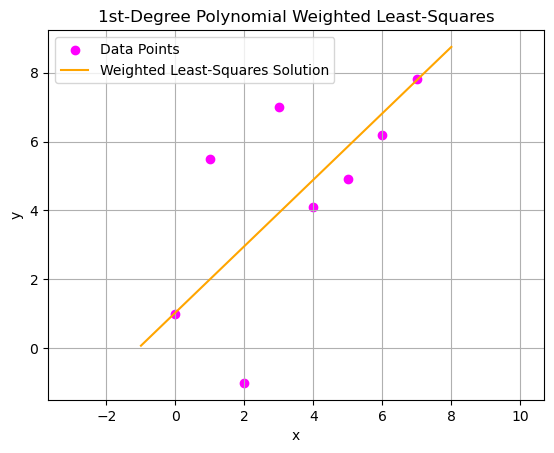

In [5]:
# specify polynomial degree
n = 1

# input data points
x = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0])
y = np.array([1.0, 5.5, -1.0, 7.0, 4.1, 4.9, 6.2, 7.8])

if len(x) != len(y):
    raise ValueError("Number of x and y coordinates must be the same")

m = len(x)

# covarience matrix
sigma = 1.0
rho = 0.9

V = np.zeros((m,m))
for i in range(m):
    for j in range(m):
        V[i,j] = sigma**2 * rho**abs(i-j)

# set up system
A = np.ones((len(x),n+1))
for i in range(len(x)):
    for j in range(n+1):
        A[i][j] = x[i]**j
b = y
A_T = np.transpose(A)
V_inv = np.linalg.solve(V, np.eye(m))

ls_soln = np.linalg.solve(A_T @ V_inv @ A, A_T @ V_inv @ b)
residual = np.linalg.norm(A @ ls_soln - b)


# smoothen data
x_smooth = np.linspace(min(x)-1,max(x)+1, 100)
y_bf = np.zeros_like(x_smooth)

for i in range(n+1):
    terms = ls_soln[i]*(x_smooth**i)
    y_bf = y_bf + terms

# display results

ols_soln = np.linalg.solve(A_T @ A, A_T @ b)
print("OLS:", ols_soln)
print("WLS:", ls_soln)


print('WLS Residual =', residual)

if (n%10 == 1) and (n%100 != 11):
    suf = 'st'
elif (n%10 == 2) and (n%100 != 12):
    suf = 'nd'
elif (n%10 == 3) and (n%100 != 13):
    suf = 'rd'
else:
    suf = 'th'

plt.scatter(x,y, color='magenta', label='Data Points')
plt.plot(x_smooth,y_bf, color='orange', label='Weighted Least-Squares Solution')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'{n}{suf}-Degree Polynomial Weighted Least-Squares')
plt.grid()
plt.legend()
plt.axis('equal') 
plt.show()